# Data Cleaning and Preprocessing Pipeline
This notebook cleans and prepares credit risk data for machine learning.

In [1]:
# Import the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

## 1. Load the Data

In [2]:
# Read the CSV file into a dataframe
df = pd.read_csv('credit_risk_dataset.csv')

print('Data loaded!')
print(df.head())

Data loaded!
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                  

In [3]:
# Check how many rows and columns we have
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])

Rows: 32581
Columns: 12


## 2. Explore the Data

In [4]:
# See column names, data types, and how many non-null values there are
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [5]:
# Get basic statistics like mean, min, max for number columns
print(df.describe())

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

In [6]:
# Find which columns are numbers and which are text
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Number columns:', numerical_cols)
print('Text columns:', categorical_cols)

Number columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length']
Text columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


## 3. Handle Missing Values
Fill missing numbers with the median. Fill missing text with the most common value.

In [7]:
# Check how many missing values each column has
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [8]:
# Fill missing number columns with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(col, 'filled with median:', median_val)

# Fill missing text columns with the most frequent value
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(col, 'filled with mode:', mode_val)

print('Missing values left:', df.isnull().sum().sum())

person_emp_length filled with median: 4.0
loan_int_rate filled with median: 10.99
Missing values left: 0


C:\Users\vaibh\AppData\Local\Temp\ipykernel_4296\1707415659.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


## 4. Remove Duplicates

In [9]:
# Check for duplicate rows
print('Duplicate rows:', df.duplicated().sum())

# Remove them
df.drop_duplicates(inplace=True)
print('Done. Rows remaining:', len(df))

Duplicate rows: 165
Done. Rows remaining: 32416


## 5. Handle Outliers
First remove impossible values, then cap extreme ones using IQR.

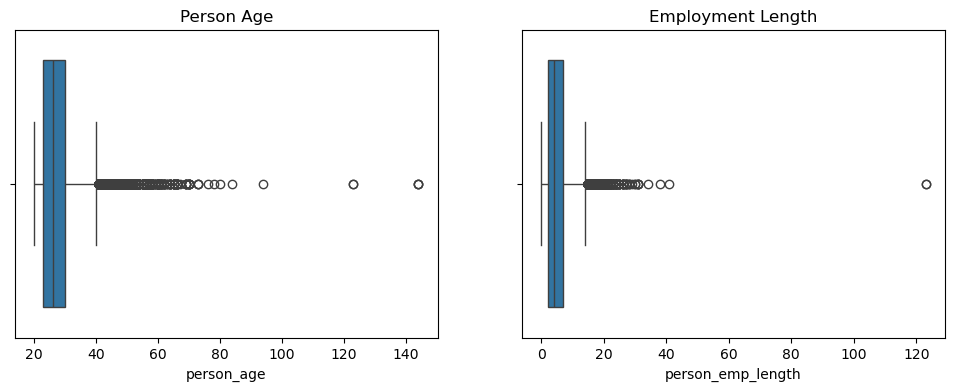

In [10]:
# Visualize outliers using boxplots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['person_age'])
plt.title('Person Age')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['person_emp_length'])
plt.title('Employment Length')

plt.show()

In [11]:
# Remove rows where age > 100 or employment > 60 years (not realistic)
before = len(df)
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]
print('Rows removed:', before - len(df))

Rows removed: 7


In [12]:
# Cap outliers in person_income using IQR
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['person_income'] = df['person_income'].clip(lower, upper)
print('person_income outliers capped')

# Cap outliers in loan_amnt using IQR
Q1 = df['loan_amnt'].quantile(0.25)
Q3 = df['loan_amnt'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df['loan_amnt'] = df['loan_amnt'].clip(lower, upper)
print('loan_amnt outliers capped')

person_income outliers capped
loan_amnt outliers capped


## 6. Encode Categorical Columns
ML models need numbers, not text. We convert text columns to numbers.

In [13]:
# Label encode loan_grade (A=0, B=1, C=2 etc.)
le = LabelEncoder()
df['loan_grade'] = le.fit_transform(df['loan_grade'])
print('loan_grade encoded')

# Convert Y/N column to 1 and 0
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})
print('cb_person_default_on_file mapped to 1/0')

loan_grade encoded
cb_person_default_on_file mapped to 1/0


In [14]:
# One-hot encode any remaining text columns
text_cols = df.select_dtypes(include=['object']).columns.tolist()
print('Columns to one-hot encode:', text_cols)

df = pd.get_dummies(df, columns=text_cols, drop_first=True)
print('One-hot encoding done')
print(df.head(3))

Columns to one-hot encode: ['person_home_ownership', 'loan_intent']
One-hot encoding done
   person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
1          21           9600                5.0           1       1000   
2          25           9600                1.0           2       5500   
3          23          65500                4.0           2      23125   

   loan_int_rate  loan_status  loan_percent_income  cb_person_default_on_file  \
1          11.14            0                 0.10                          0   
2          12.87            1                 0.57                          0   
3          15.23            1                 0.53                          0   

   cb_person_cred_hist_length  person_home_ownership_OTHER  \
1                           2                        False   
2                           3                        False   
3                           2                        False   

   person_home_ownership_OWN  person_ho

## 7. Scale the Features
Scale number columns so they all have a similar range.

In [15]:
# Separate features (X) and target (y)
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# List the columns we want to scale
cols_to_scale = ['person_age', 'person_income', 'person_emp_length',
                 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length']

# Only keep columns that actually exist in X
cols_to_scale = [c for c in cols_to_scale if c in X.columns]

scaler = StandardScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

print('Scaling done')
print(X.head(3))

Scaling done
   person_age  person_income  person_emp_length  loan_grade  loan_amnt  \
1   -1.083796      -1.661220           0.059888           1  -1.444435   
2   -0.439710      -1.661220          -0.944205           2  -0.672231   
3   -0.761753       0.096624          -0.191135           2   2.352239   

   loan_int_rate  loan_percent_income  cb_person_default_on_file  \
1       0.040702                 0.10                          0   
2       0.601834                 0.57                          0   
3       1.367308                 0.53                          0   

   cb_person_cred_hist_length  person_home_ownership_OTHER  \
1                   -0.939218                        False   
2                   -0.692782                        False   
3                   -0.939218                        False   

   person_home_ownership_OWN  person_home_ownership_RENT  \
1                       True                       False   
2                      False                    

## 8. Check Feature Correlations

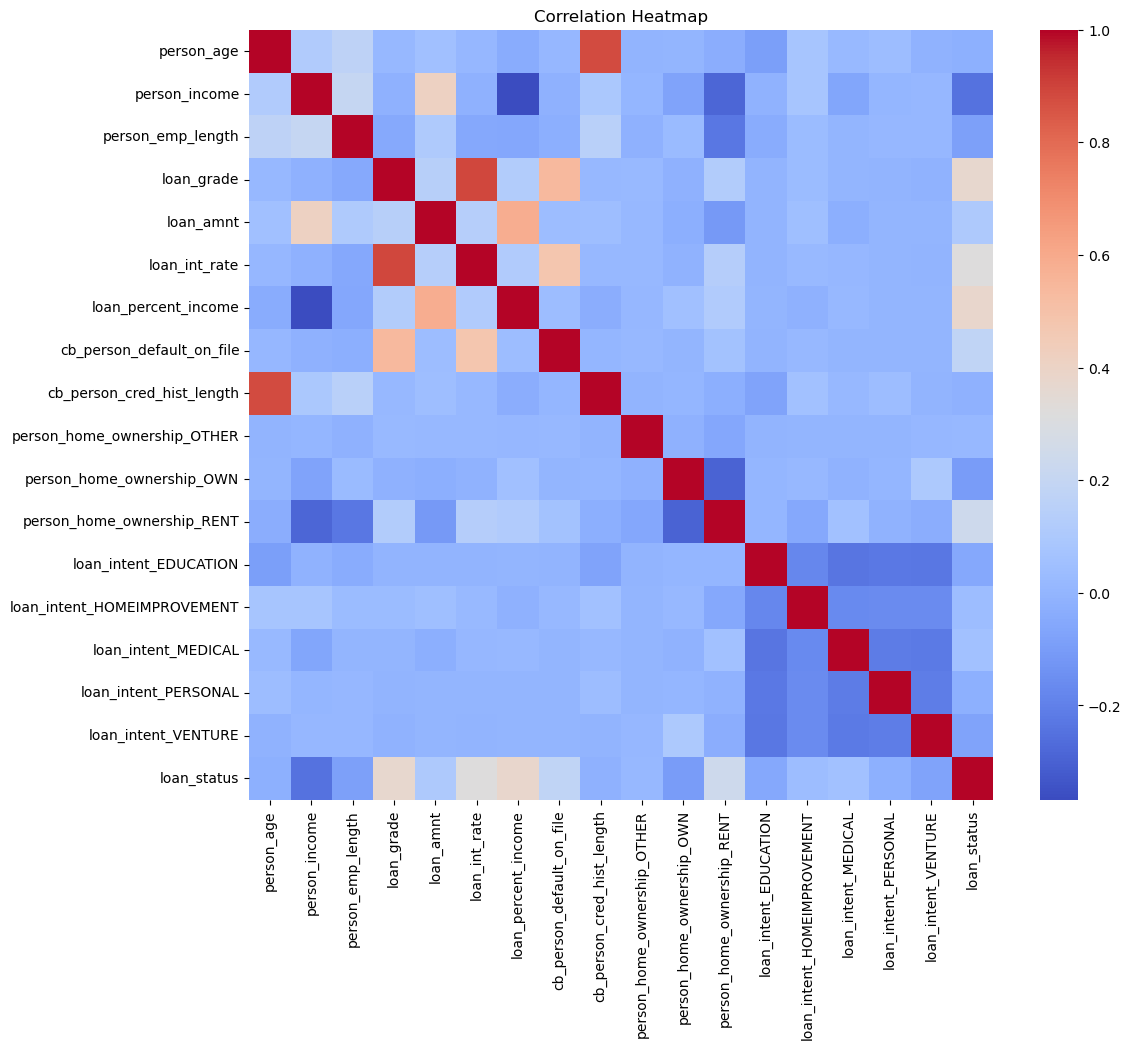

In [16]:
# Combine X and y to check correlations
df_final = pd.concat([X, y], axis=1)

# Compute and plot the correlation matrix
corr = df_final.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [17]:
# Print any column pairs that are very strongly correlated (over 0.8)
print('Highly correlated pairs (> 0.8):')
found = False
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.8:
            print(corr.columns[i], 'and', corr.columns[j])
            found = True

if not found:
    print('No highly correlated pairs found.')

Highly correlated pairs (> 0.8):
loan_int_rate and loan_grade
cb_person_cred_hist_length and person_age


## 9. Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_ready = df_final.drop('loan_status', axis=1)
y_ready = df_final['loan_status']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_ready, y_ready, test_size=0.2, random_state=42, stratify=y_ready
)

print('Training rows:', X_train.shape[0])
print('Testing rows:', X_test.shape[0])

Training rows: 25927
Testing rows: 6482


## 10. Handle Class Imbalance with SMOTE
There are many more non-defaults than defaults. SMOTE balances this out.

In [19]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('After SMOTE:')
print(y_train_smote.value_counts())

Before SMOTE:
loan_status
0    20257
1     5670
Name: count, dtype: int64
After SMOTE:
loan_status
0    20257
1    20257
Name: count, dtype: int64


## 11. Train the Models

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Create the models
lr_model = LogisticRegression(random_state=42, max_iter=1000)
nb_model = GaussianNB()

# Train both models
lr_model.fit(X_train_smote, y_train_smote)
print('Logistic Regression trained')

nb_model.fit(X_train_smote, y_train_smote)
print('Naive Bayes trained')

Logistic Regression trained
Naive Bayes trained


## 12. Evaluate the Models

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predictions for both models
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

# Print metrics for Logistic Regression
print('--- Logistic Regression ---')
print('Accuracy: ', round(accuracy_score(y_test, y_pred_lr) * 100, 2), '%')
print('Precision:', round(precision_score(y_test, y_pred_lr) * 100, 2), '%')
print('Recall:   ', round(recall_score(y_test, y_pred_lr) * 100, 2), '%')
print('F1 Score: ', round(f1_score(y_test, y_pred_lr) * 100, 2), '%')
print('AUC-ROC:  ', round(roc_auc_score(y_test, y_prob_lr) * 100, 2), '%')

print()

# Print metrics for Naive Bayes
print('--- Naive Bayes ---')
print('Accuracy: ', round(accuracy_score(y_test, y_pred_nb) * 100, 2), '%')
print('Precision:', round(precision_score(y_test, y_pred_nb) * 100, 2), '%')
print('Recall:   ', round(recall_score(y_test, y_pred_nb) * 100, 2), '%')
print('F1 Score: ', round(f1_score(y_test, y_pred_nb) * 100, 2), '%')
print('AUC-ROC:  ', round(roc_auc_score(y_test, y_prob_nb) * 100, 2), '%')

--- Logistic Regression ---
Accuracy:  79.02 %
Precision: 51.34 %
Recall:    78.42 %
F1 Score:  62.05 %
AUC-ROC:   86.44 %

--- Naive Bayes ---
Accuracy:  77.21 %
Precision: 48.69 %
Recall:    77.57 %
F1 Score:  59.83 %
AUC-ROC:   84.3 %


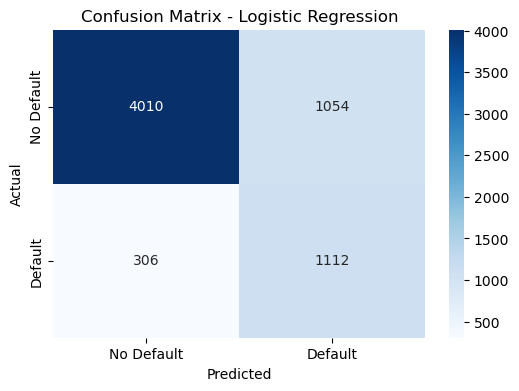

In [22]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

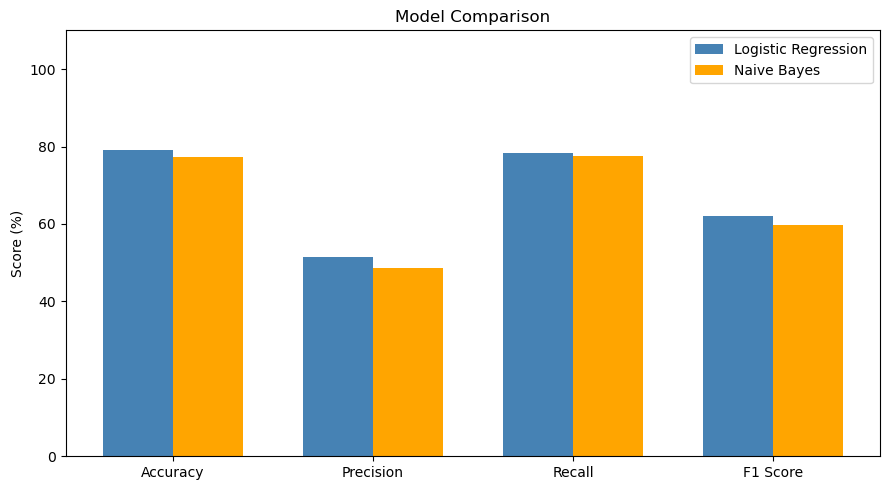

In [23]:
# Bar chart comparing both models side by side
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lr_scores = [
    accuracy_score(y_test, y_pred_lr) * 100,
    precision_score(y_test, y_pred_lr) * 100,
    recall_score(y_test, y_pred_lr) * 100,
    f1_score(y_test, y_pred_lr) * 100
]

nb_scores = [
    accuracy_score(y_test, y_pred_nb) * 100,
    precision_score(y_test, y_pred_nb) * 100,
    recall_score(y_test, y_pred_nb) * 100,
    f1_score(y_test, y_pred_nb) * 100
]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
ax.bar(x + width/2, nb_scores, width, label='Naive Bayes', color='orange')

ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()